### 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as lines
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/samplesuperstore/SampleSuperstore.csv


In [2]:
df = pd.read_csv("/kaggle/input/samplesuperstore/SampleSuperstore.csv")
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9993 entries, 0 to 9992
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9993 non-null   object 
 1   Segment       9993 non-null   object 
 2   Country       9993 non-null   object 
 3   City          9993 non-null   object 
 4   State         9993 non-null   object 
 5   Postal Code   9993 non-null   int64  
 6   Region        9993 non-null   object 
 7   Category      9993 non-null   object 
 8   Sub-Category  9993 non-null   object 
 9   Sales         9993 non-null   float64
 10  Quantity      9993 non-null   int64  
 11  Discount      9993 non-null   float64
 12  Profit        9993 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.0+ KB


In [4]:
df.duplicated().sum()

17

In [5]:
df.drop_duplicates(inplace=True)

In [6]:
df.columns

Index(['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')

In [7]:
df['Ship Mode'].value_counts().to_frame()

,Ship Mode
Standard Class,5955
Second Class,1942
First Class,1537
Same Day,542


In [8]:
df['Segment'].value_counts().to_frame()

,Segment
Consumer,5182
Corporate,3015
Home Office,1779


In [9]:
df['Country'].value_counts().to_frame()

,Country
United States,9976


In [10]:
df['State'].value_counts().to_frame()

,State
California,1995
New York,1127
Texas,983
Pennsylvania,586
Washington,502
Illinois,491
Ohio,468
Florida,383
Michigan,254
North Carolina,249


In [11]:
df['City'].value_counts().to_frame()

,City
New York City,914
Los Angeles,746
Philadelphia,536
San Francisco,506
Seattle,424
...,...
Glenview,1
Missouri City,1
Rochester Hills,1
Palatine,1


In [12]:
df['Region'].value_counts().to_frame()

,Region
West,3192
East,2845
Central,2319
South,1620


In [13]:
df['Category'].value_counts().to_frame()

,Category
Office Supplies,6011
Furniture,2118
Technology,1847


In [14]:
df['Sub-Category'].value_counts().to_frame()

,Sub-Category
Binders,1522
Paper,1359
Furnishings,956
Phones,889
Storage,846
Art,795
Accessories,775
Chairs,615
Appliances,465
Labels,363


**drop postalcode column which useless

In [15]:
df.drop(columns='Postal Code',inplace=True)

In [16]:
#country column doesnt give any inofmation where as US is the only countery exist 
df.drop(columns='Country',inplace=True)

In [17]:
df.describe()

,Sales,Quantity,Discount,Profit
count,9976.000000,9976.000000,9976.000000,9976.000000
mean,230.147597,3.790898,0.156294,28.685693
std,623.752659,2.226696,0.206460,234.469173
min,0.444000,1.000000,0.000000,-6599.978000
25%,17.295000,2.000000,0.000000,1.725850
50%,54.804000,3.000000,0.200000,8.666500
75%,209.970000,5.000000,0.200000,29.366000
max,22638.480000,14.000000,0.800000,8399.976000


In [18]:
df.sample(5)

,Ship Mode,Segment,City,State,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
8660,Standard Class,Consumer,Fort Lauderdale,Florida,South,Furniture,Bookcases,723.920,5,0.2,-81.4410
1466,Standard Class,Consumer,Glendale,Arizona,West,Technology,Accessories,95.976,3,0.2,-10.7973
3705,Standard Class,Corporate,Decatur,Alabama,South,Office Supplies,Paper,32.400,5,0.0,15.5520
800,First Class,Corporate,San Diego,California,West,Furniture,Furnishings,22.230,1,0.0,7.3359
9919,Standard Class,Corporate,Bryan,Texas,Central,Furniture,Chairs,528.430,5,0.3,-143.4310


<AxesSubplot:>

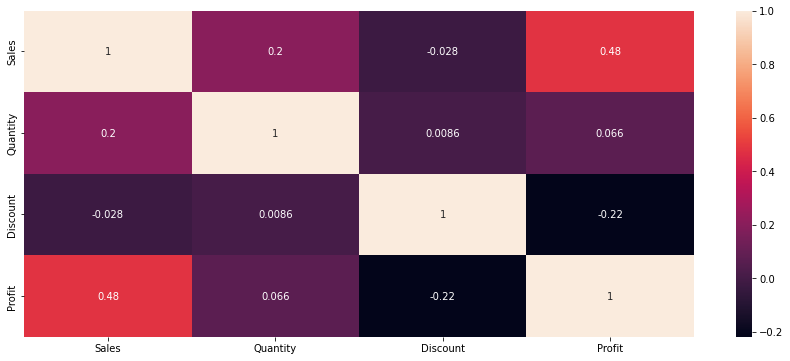

In [19]:
plt.figure(figsize=(15,6))
sns.heatmap(df.corr(),annot=True)

Profit and discount have a significant negative correlation, while profit and sales have a large positive correlation.

## 1- Analysis based on Category and Sub-Category

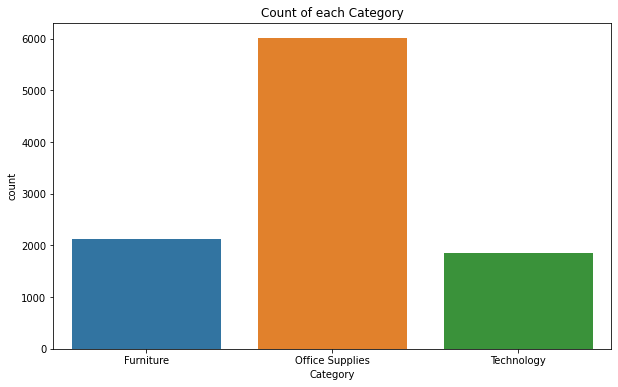

In [20]:
plt.figure(figsize=(10,6))
sns.countplot(x='Category',data = df)
plt.title("Count of each Category")
plt.show();

Office supplies is the most plopluer Category

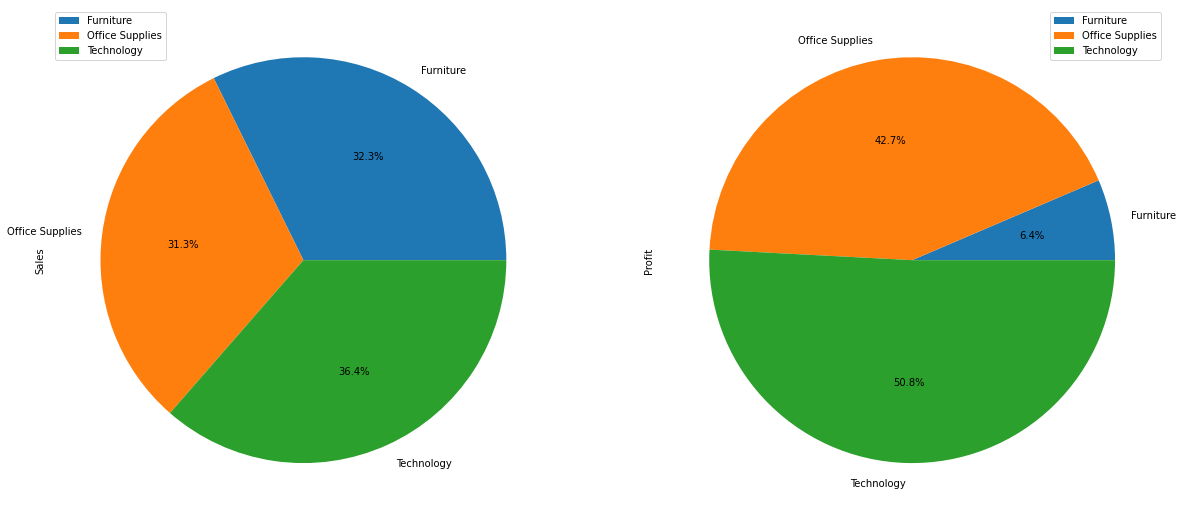

In [21]:
df_categ = df.groupby(['Category']).sum()[['Profit','Sales']]
df_categ[['Sales','Profit']].plot.pie(subplots=True, figsize=(20,10),autopct='%1.1f%%');

There are three types of category available.
We infer that sales volume is almost equal for each category based on the analysis of sales and profit for each category.
However, the profit in the furniture category is the smallest

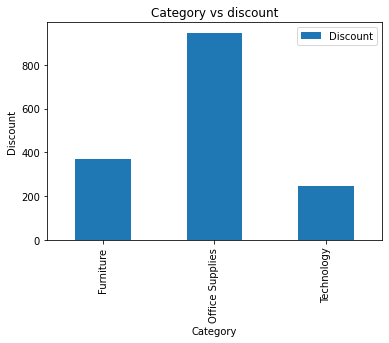

In [22]:
df.groupby(['Category']).sum()[['Discount']].plot.bar()
plt.title("Category vs discount")
plt.ylabel('Discount');

Because I have a negative correlation between corer and discount, Office Supplies should be the lowest profit, but Furniture is the lowest profit.

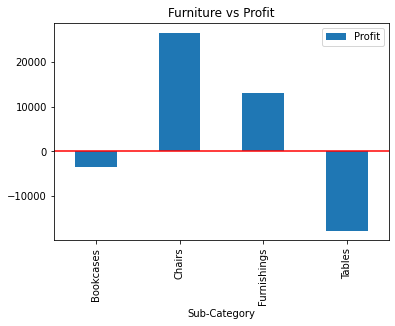

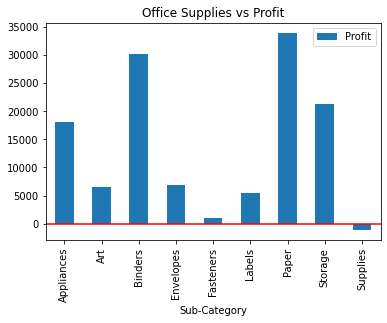

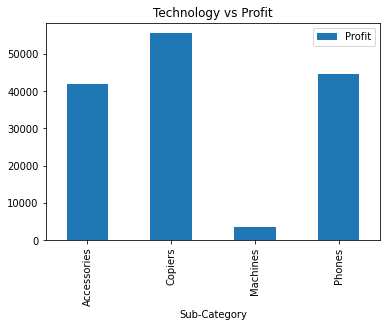

In [23]:
df_Furniture = df.set_index(['Category']).loc['Furniture']
df_Office = df.set_index(['Category']).loc['Office Supplies']
df_Technology = df.set_index(['Category']).loc['Technology']

df_Furniture[['Sub-Category','Profit']].groupby('Sub-Category').sum().plot.bar(title='Furniture vs Profit')
plt.axhline(0,color='r')

df_Office[['Sub-Category','Profit']].groupby('Sub-Category').sum().plot.bar(title='Office Supplies vs Profit')
plt.axhline(0,color='r')

df_Technology[['Sub-Category','Profit']].groupby('Sub-Category').sum().plot.bar(title='Technology vs Profit');


Furniture has lost in tables and bookcases, Office Supplies has a small loss in supplies, while Technology has no losses in any sub-category.

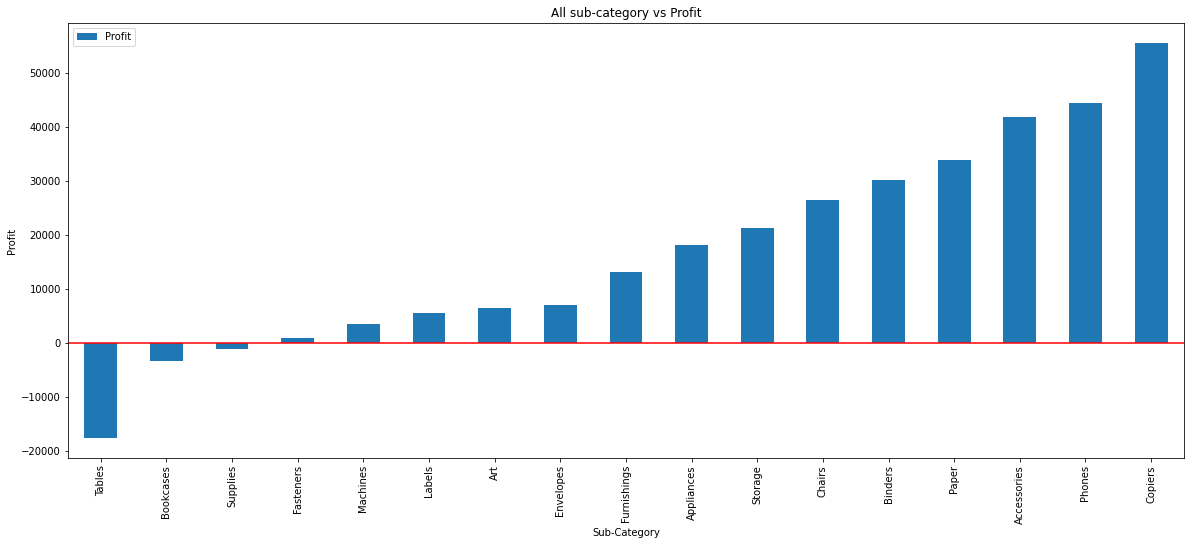

In [24]:
df[['Sub-Category','Profit']].groupby('Sub-Category').sum().sort_values('Profit').plot.bar(figsize=(20,8))                                                                                     
plt.axhline(0,color='r')
plt.title('All sub-category vs Profit')
plt.ylabel('Profit');

### Is there a product that either loses or wins all the time? If so, what exactly is this product?

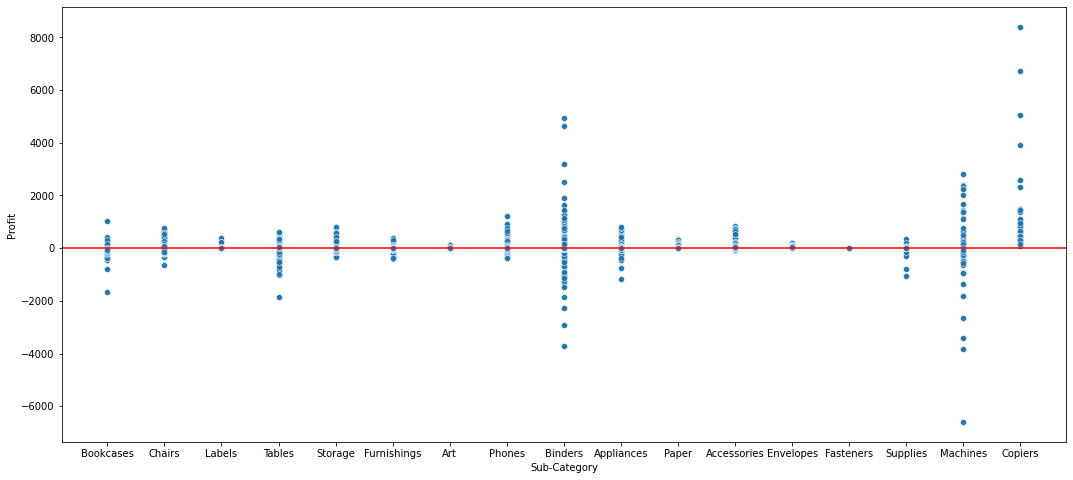

In [25]:
plt.figure(figsize=(18,8))
graph = sns.scatterplot(y='Profit',x='Sub-Category',data=df)
graph.axhline(0,color='r')
plt.show()

There are products that lose and win, thus there are no items that always lose, but there are products that always win (Art, Paper, Envelopes, Copiers)

## 2- Analysis based on State

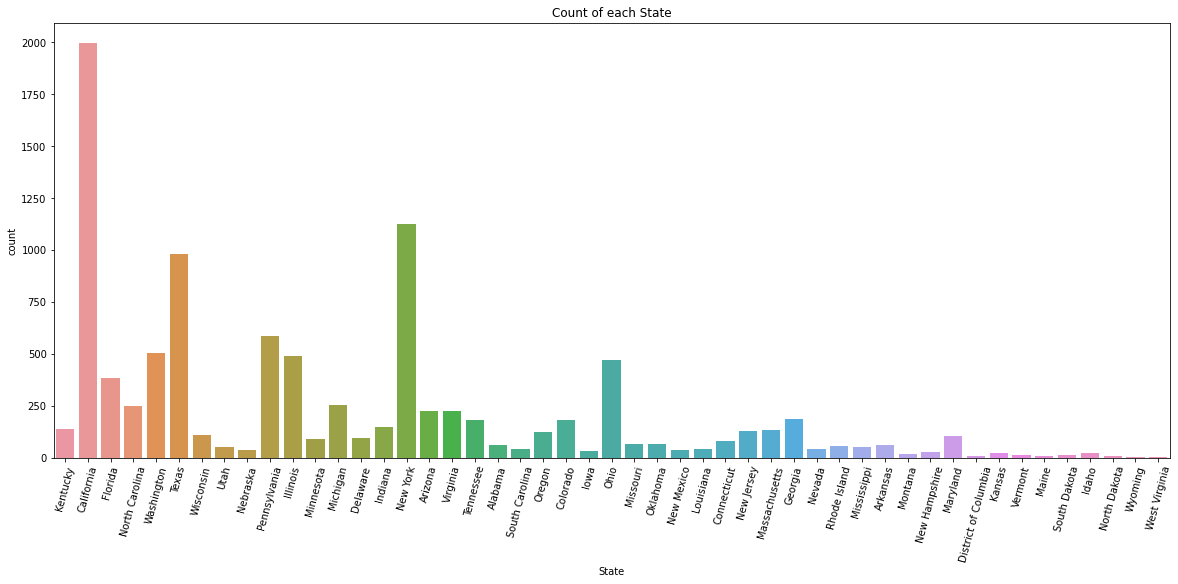

In [26]:
plt.figure(figsize=(20,8))
sns.countplot(data=df,x='State')
plt.xticks(rotation=75)
plt.title('Count of each State')
plt.show()

California is the most populer State followed by New York

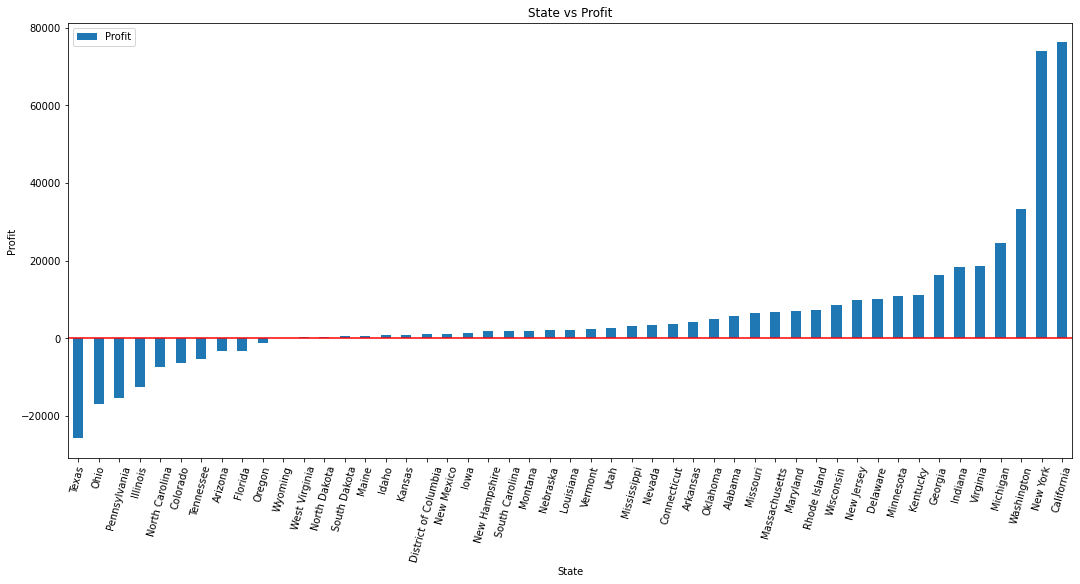

In [27]:
df.groupby(['State']).sum()[['Profit']].sort_values(['Profit']).plot.bar(figsize=(18,8))
plt.ylabel("Profit")
plt.xticks(rotation=75)
plt.axhline(0,color='r')
plt.title('State vs Profit');

The highest profits are in California and New York, while the lowest profits are in Texas.

In [28]:
state_code = {'Alabama': 'AL','Alaska': 'AK','Arizona': 'AZ','Arkansas': 'AR','California': 'CA','Colorado': 'CO',
              'Connecticut': 'CT','Delaware': 'DE','Florida': 'FL','Georgia': 'GA','Hawaii': 'HI','Idaho': 'ID',
              'Illinois': 'IL','Indiana': 'IN','Iowa': 'IA','Kansas': 'KS','Kentucky': 'KY','Louisiana': 'LA',
              'Maine': 'ME','Maryland': 'MD','Massachusetts': 'MA','Michigan': 'MI','Minnesota': 'MN',
              'Mississippi': 'MS','Missouri': 'MO','Montana': 'MT','Nebraska': 'NE','Nevada': 'NV',
              'New Hampshire': 'NH','New Jersey': 'NJ','New Mexico': 'NM','New York': 'NY','North Carolina': 'NC',
              'North Dakota': 'ND','Ohio': 'OH','Oklahoma': 'OK','Oregon': 'OR','Pennsylvania': 'PA',
              'Rhode Island': 'RI','South Carolina': 'SC','South Dakota': 'SD','Tennessee': 'TN','Texas': 'TX','Utah': 'UT',
              'Vermont': 'VT','Virginia': 'VA','District of Columbia': 'WA','Washington': 'WA','West Virginia': 'WV',
              'Wisconsin': 'WI','Wyoming': 'WY'}
df['state_code'] = df.State.apply(lambda x: state_code[x])

In [29]:
state_data = df[['Profit', 'state_code']].groupby(['state_code']).sum()
fig = go.Figure(data=go.Choropleth(
    locations=state_data.index, 
    z = state_data.Profit, 
    locationmode = 'USA-states', 
    colorscale = 'YlOrRd',
    colorbar_title = 'Profit in USA')) 
fig.update_layout(
    title_text = 'Total State-Wise Profit',
    geo_scope='usa',)
fig.show();

We can draw from this map that the weak states with little profit are (Texas, Pennsylvania, Ohio), whereas the profitable states are (California, New York)

### Is there a State that either loses or wins all the time?

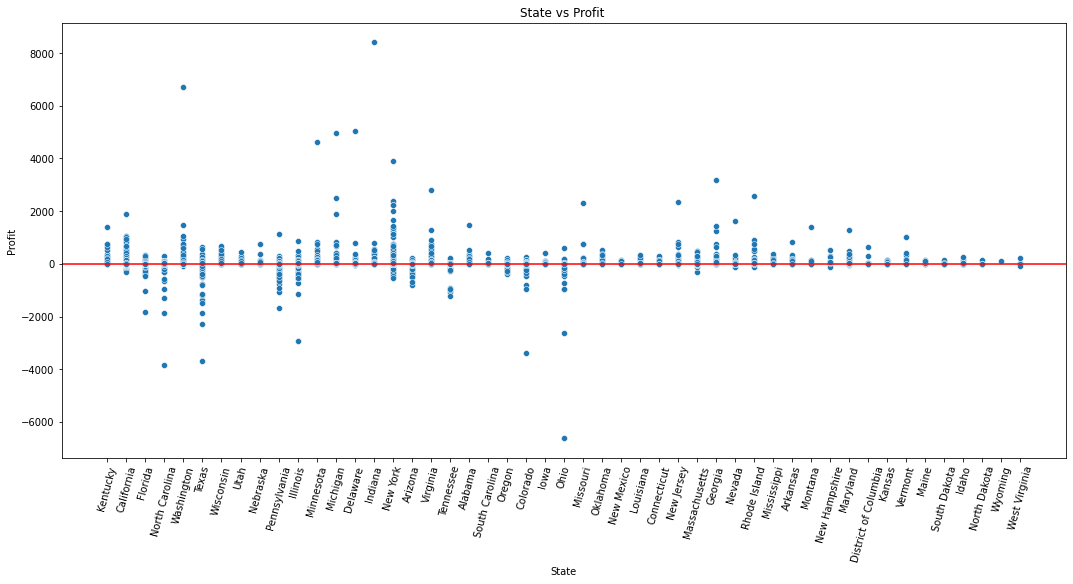

In [30]:
plt.figure(figsize=(18,8))
sns.scatterplot(y='Profit',x='State',data=df)
plt.axhline(0,color='r')
plt.xticks(rotation=75)
plt.title("State vs Profit ")
plt.show()

We can see from this graph that the majority of states lose and win, but some states only win, such as (Wyoming)and other.

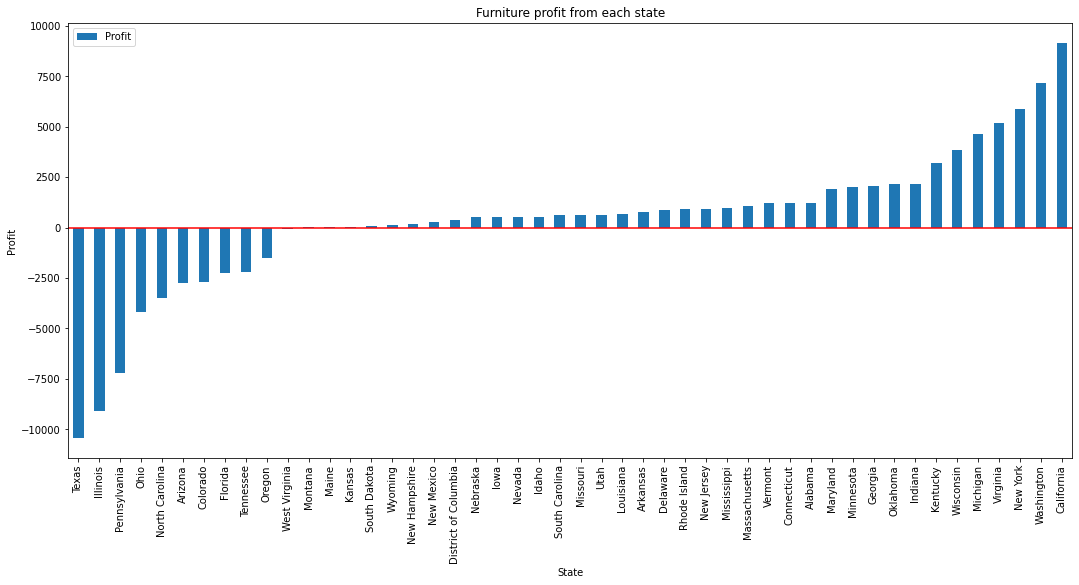

In [31]:
df_Furniture.groupby('State').sum()[['Profit']].sort_values('Profit').plot.bar(figsize=(18,8))
plt.axhline(0,color='r')
plt.title('Furniture profit from each state')
plt.ylabel('Profit');

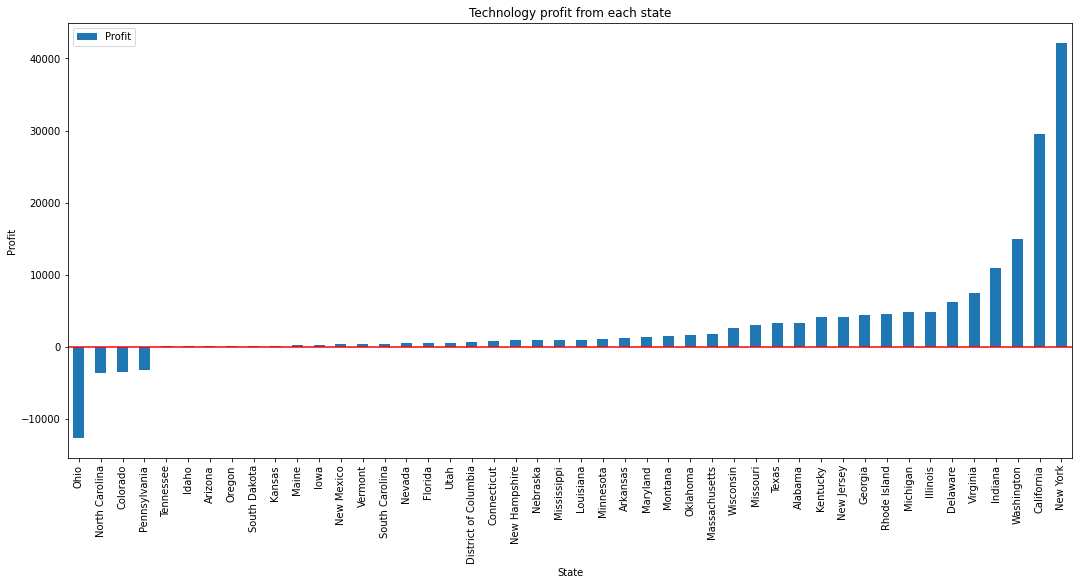

In [32]:
df_Technology.groupby('State').sum()[['Profit']].sort_values('Profit').plot.bar(figsize=(18,8))
plt.axhline(0,color='r')
plt.title('Technology profit from each state')
plt.ylabel('Profit');

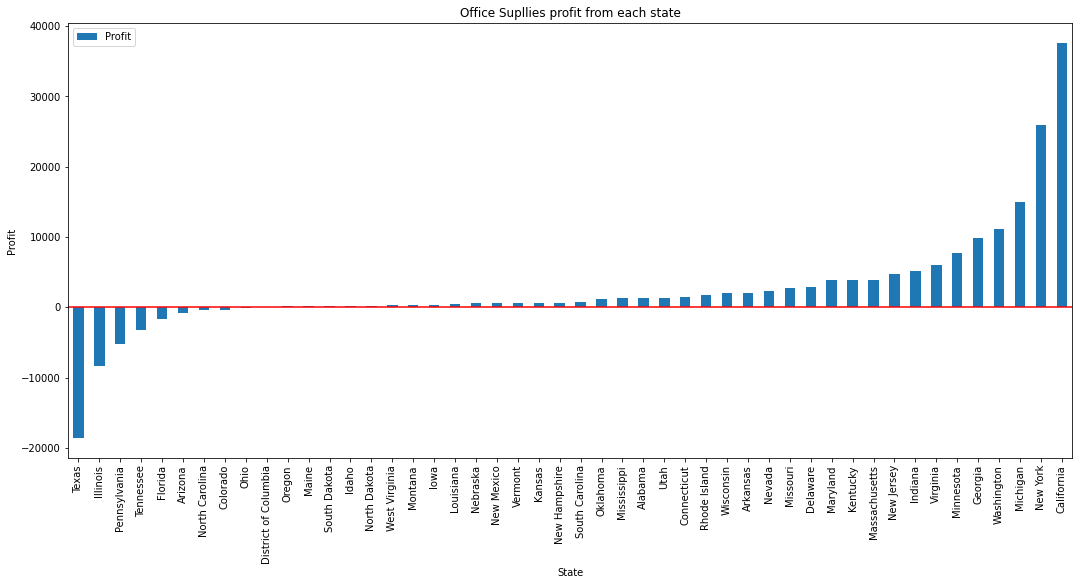

In [33]:
df_Office.groupby('State').sum()[['Profit']].sort_values('Profit').plot.bar(figsize=(18,8))
plt.axhline(0,color='r')
plt.title('Office Supllies profit from each state')
plt.ylabel('Profit');

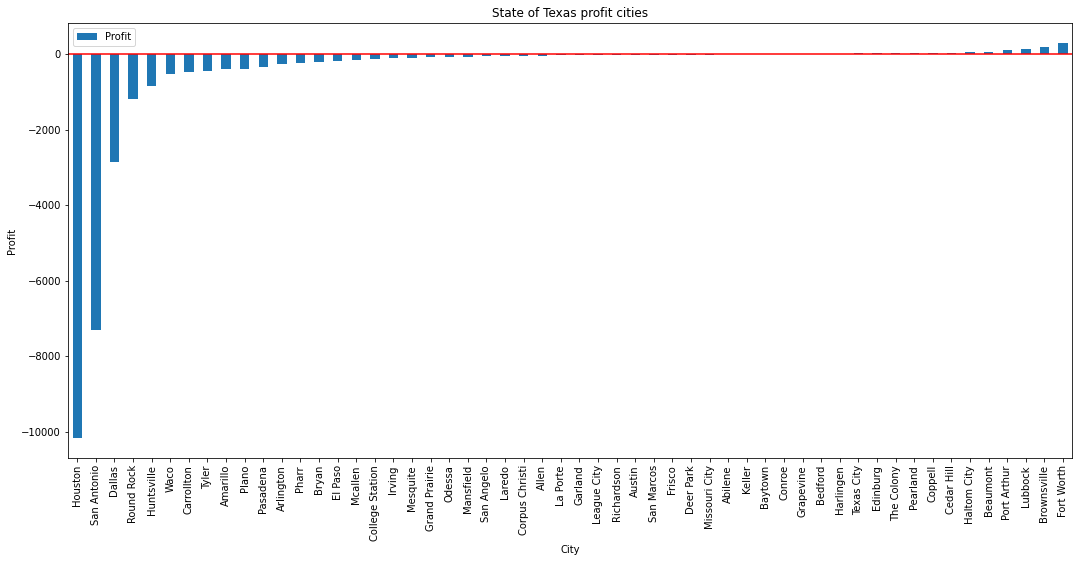

In [34]:
texas_df = df.set_index(['State']).loc['Texas']
texas_df.groupby('City').sum()[['Profit']].sort_values('Profit').plot.bar(figsize=(18,8))
plt.axhline(0,color='r')
plt.title('State of Texas profit cities')
plt.ylabel('Profit');

## 3-Analysis based on Segmant

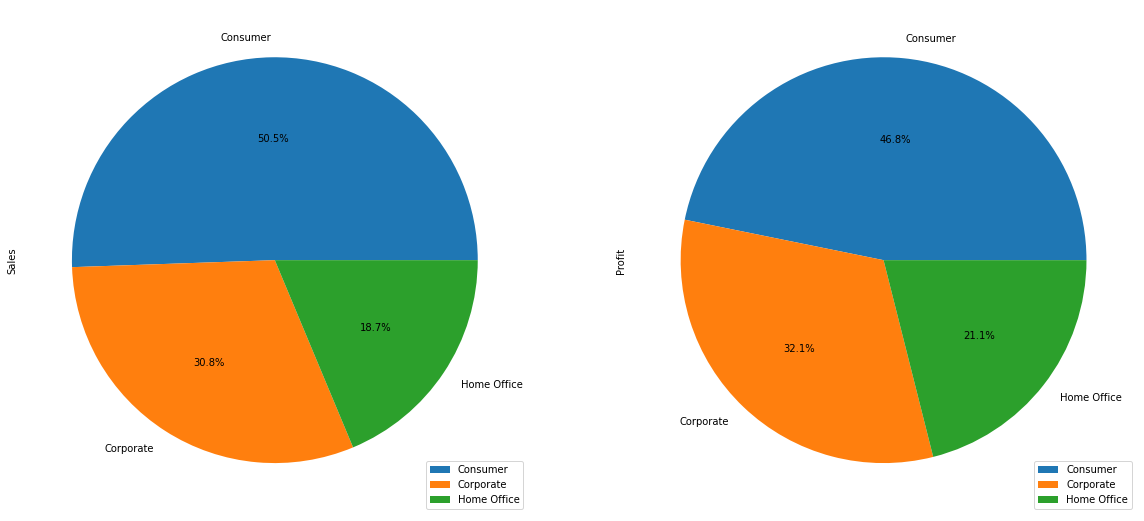

In [35]:
df_categ = df.groupby(['Segment']).sum()[['Profit','Sales']]
df_categ[['Sales','Profit']].plot.pie(subplots=True, figsize=(20,10),autopct='%1.1f%%');

## 4-Anaysis based on Ship Mode

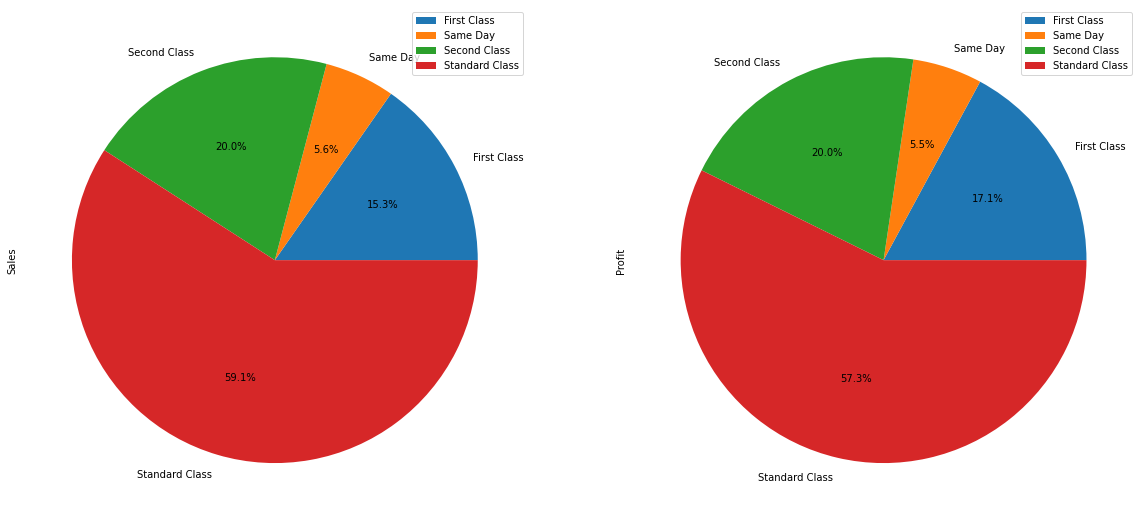

In [36]:
df_categ = df.groupby(['Ship Mode']).sum()[['Profit','Sales']]
df_categ[['Sales','Profit']].plot.pie(subplots=True, figsize=(20,10),autopct='%1.1f%%');

## Concluion

There are three types of categories (Office Supllies, Technology, Furniture)
1. Their sales are comparable, but the furniture category's profits are the lowest.
2. There are sub-categories that have been lost within the three categories, such as Tables and bookcases inside the furniture and supplies within the Office Supllies category.
3. In states, Texas is the most losing, while California is the most profitable.
4. In Segment, The percentage of sales and profits are fairly close.
5. In Shipe Mode, The percentage of sales and profits are fairly close.